# Workforce Burnout & Attrition Intelligence System

This notebook walks through the complete data analytics and machine learning pipeline for predicting employee attrition and identifying burnout patterns using the IBM HR Analytics dataset.

**Objective:** Build a system that helps HR teams identify at-risk employees, understand attrition drivers, and take proactive retention measures.

**Dataset:** IBM HR Analytics Employee Attrition (1,470 employees, 35 features)

## 1. Import Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import pickle
import warnings
warnings.filterwarnings('ignore')

## 2. Load and Inspect the Dataset

In [28]:
df = pd.read_csv('../data/employee_attrition.csv')
print(f'Dataset Shape: {df.shape}')
print(f'Total Employees: {df.shape[0]}')
print(f'Total Features: {df.shape[1]}')
df.head()

Dataset Shape: (1470, 35)
Total Employees: 1470
Total Features: 35


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [30]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [31]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

## 3. Data Cleaning & Preprocessing

The IBM HR dataset is relatively clean. We need to:
- Check for missing values
- Drop columns that have constant values (no predictive power)
- Identify categorical vs numerical features

In [32]:
print('Missing Values:')
print(df.isnull().sum().sum())
print('\nDuplicate Rows:', df.duplicated().sum())

Missing Values:
0

Duplicate Rows: 0


In [33]:
print('Columns with constant values:')
for col in df.columns:
    if df[col].nunique() == 1:
        print(f'  {col}: {df[col].unique()[0]}')

Columns with constant values:
  EmployeeCount: 1
  Over18: Y
  StandardHours: 80


In [34]:
drop_cols = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df_clean = df.drop(columns=drop_cols)
print(f'Shape after dropping: {df_clean.shape}')

Shape after dropping: (1470, 31)


In [35]:
categorical = df_clean.select_dtypes(include='object').columns.tolist()
numerical = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f'Categorical columns ({len(categorical)}): {categorical}')
print(f'Numerical columns ({len(numerical)}): {numerical}')

Categorical columns (8): ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Numerical columns (23): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## 4. Exploratory Data Analysis

Let's dig into the data to understand patterns behind employee attrition.

### 4.1 Attrition Distribution

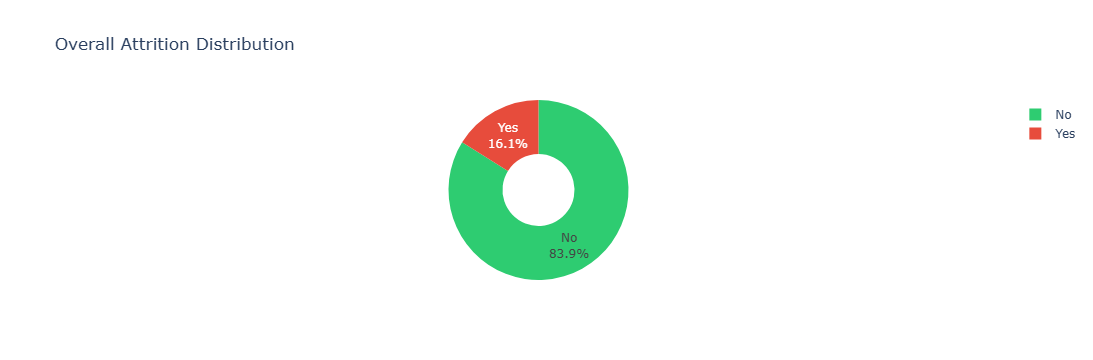

In [36]:
counts = df_clean['Attrition'].value_counts().reset_index()
counts.columns = ['Attrition', 'Count']
fig = px.pie(counts, values='Count', names='Attrition', title='Overall Attrition Distribution',
             color_discrete_sequence=['#2ecc71', '#e74c3c'], hole=0.4)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

Around 16% of employees left the company. This is a class-imbalanced problem which is typical in HR attrition datasets.

### 4.2 Department-wise Attrition

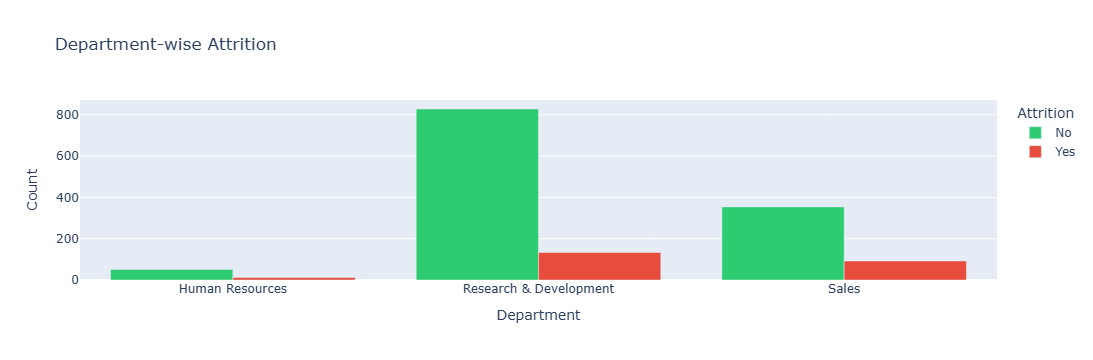

In [37]:
dept = df_clean.groupby(['Department', 'Attrition']).size().reset_index(name='Count')
fig = px.bar(dept, x='Department', y='Count', color='Attrition', barmode='group',
             title='Department-wise Attrition', color_discrete_map={'Yes': '#e74c3c', 'No': '#2ecc71'})
fig.show()

R&D has the highest absolute attrition count, but that's also the largest department. Sales has a relatively higher attrition *rate*.

### 4.3 Overtime vs Attrition

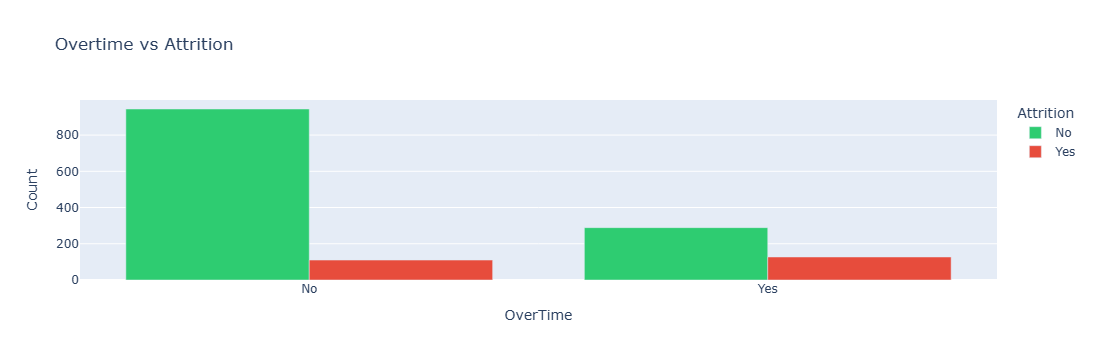

In [38]:
ot = df_clean.groupby(['OverTime', 'Attrition']).size().reset_index(name='Count')
fig = px.bar(ot, x='OverTime', y='Count', color='Attrition', barmode='group',
             title='Overtime vs Attrition', color_discrete_map={'Yes': '#e74c3c', 'No': '#2ecc71'})
fig.show()

Employees working overtime have a significantly higher attrition rate. This is one of the strongest predictors.

### 4.4 Monthly Income vs Attrition

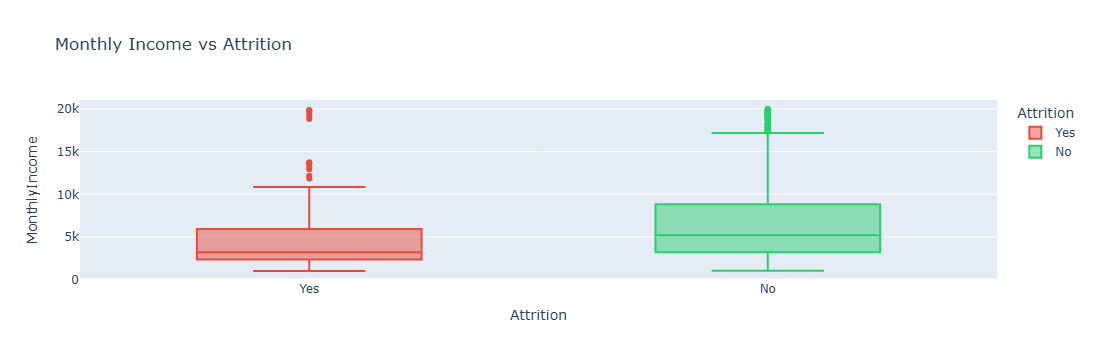

In [39]:
fig = px.box(df_clean, x='Attrition', y='MonthlyIncome', title='Monthly Income vs Attrition',
             color='Attrition', color_discrete_map={'Yes': '#e74c3c', 'No': '#2ecc71'})
fig.show()

Employees who left tend to have lower monthly incomes. Compensation is clearly a retention factor.

### 4.5 Job Satisfaction vs Attrition

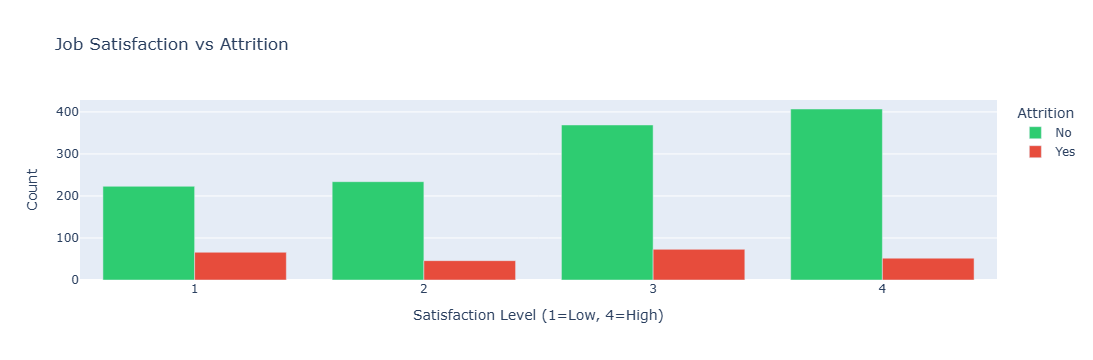

In [40]:
sat = df_clean.groupby(['JobSatisfaction', 'Attrition']).size().reset_index(name='Count')
sat['JobSatisfaction'] = sat['JobSatisfaction'].astype(str)
fig = px.bar(sat, x='JobSatisfaction', y='Count', color='Attrition', barmode='group',
             title='Job Satisfaction vs Attrition',
             color_discrete_map={'Yes': '#e74c3c', 'No': '#2ecc71'},
             labels={'JobSatisfaction': 'Satisfaction Level (1=Low, 4=High)'})
fig.show()

### 4.6 Work-Life Balance vs Attrition

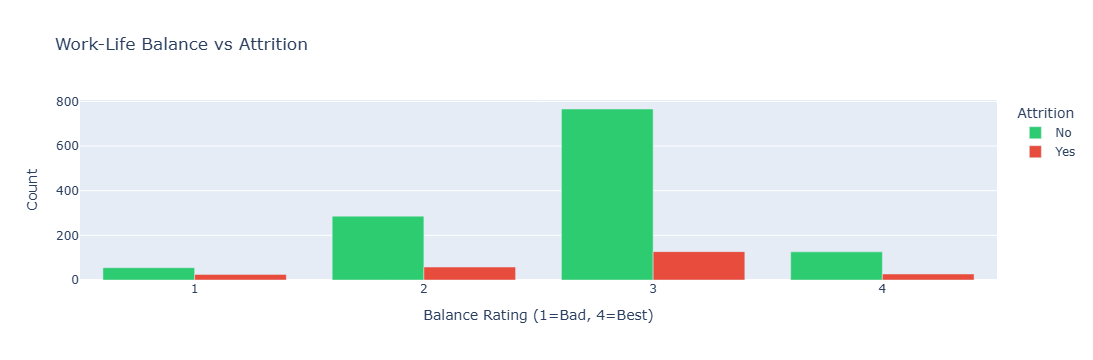

In [41]:
wlb = df_clean.groupby(['WorkLifeBalance', 'Attrition']).size().reset_index(name='Count')
wlb['WorkLifeBalance'] = wlb['WorkLifeBalance'].astype(str)
fig = px.bar(wlb, x='WorkLifeBalance', y='Count', color='Attrition', barmode='group',
             title='Work-Life Balance vs Attrition',
             color_discrete_map={'Yes': '#e74c3c', 'No': '#2ecc71'},
             labels={'WorkLifeBalance': 'Balance Rating (1=Bad, 4=Best)'})
fig.show()

### 4.7 Age Distribution by Attrition

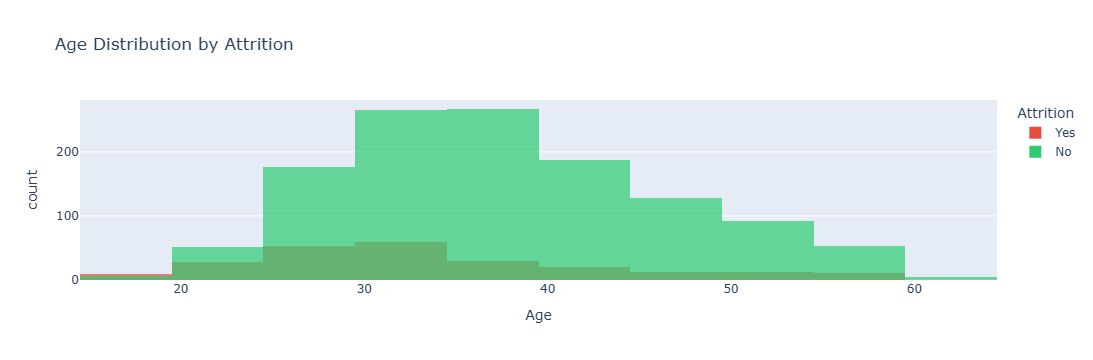

In [42]:
fig = px.histogram(df_clean, x='Age', color='Attrition', barmode='overlay', nbins=20,
                   title='Age Distribution by Attrition',
                   color_discrete_map={'Yes': '#e74c3c', 'No': '#2ecc71'}, opacity=0.7)
fig.show()

Younger employees (25-35) show higher attrition rates, likely due to career exploration and job hopping tendencies.

### 4.8 Correlation Heatmap

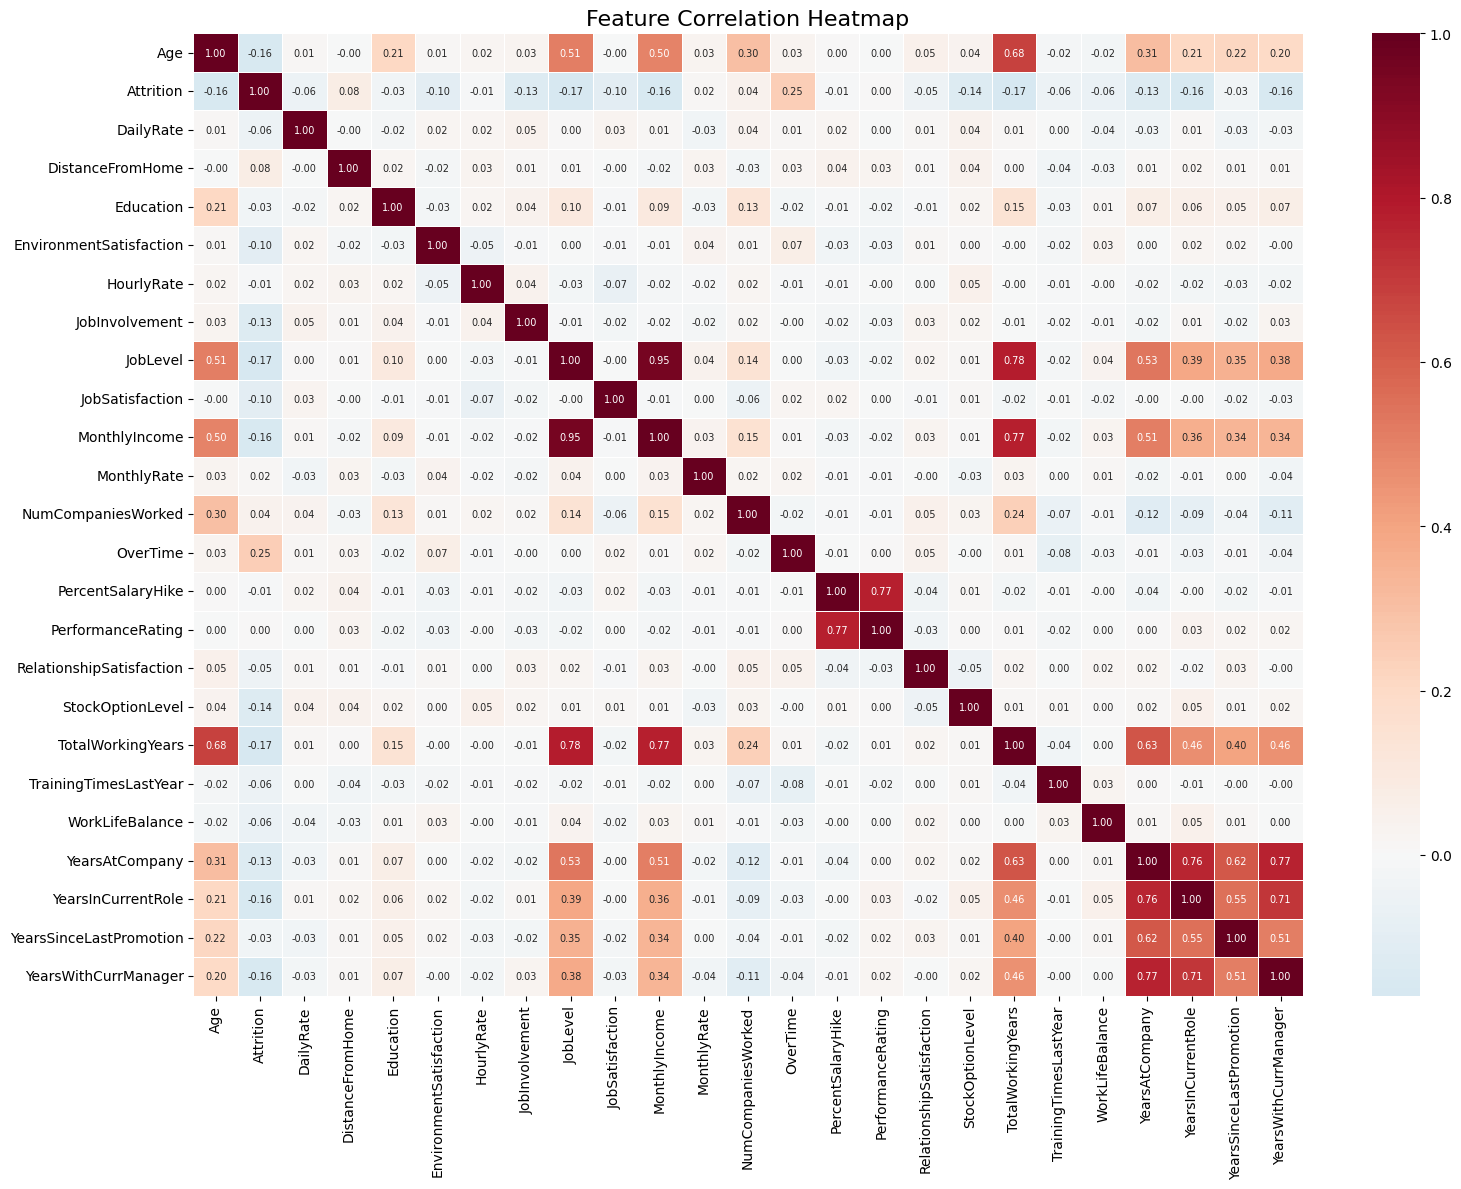

In [43]:
df_corr = df_clean.copy()
df_corr['Attrition'] = df_corr['Attrition'].map({'Yes': 1, 'No': 0})
df_corr['OverTime'] = df_corr['OverTime'].map({'Yes': 1, 'No': 0})
numeric_df = df_corr.select_dtypes(include=[np.number])

plt.figure(figsize=(16, 12))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

Key correlations with Attrition: OverTime (positive), JobLevel/MonthlyIncome (negative), TotalWorkingYears (negative).

## 5. Burnout Score System

We create a custom burnout risk score using a weighted formula based on key workplace stress factors. The weights are designed to reflect real-world impact on employee wellbeing:

| Factor | Weight | Logic |
|--------|--------|-------|
| Overtime | 30 pts | Working overtime is the strongest burnout driver |
| Job Satisfaction | 20 pts | Low satisfaction (inverted 1-4 scale) |
| Work-Life Balance | 20 pts | Poor balance (inverted 1-4 scale) |
| Years Since Promotion | 15 pts | Career stagnation (capped at 10 years) |
| Monthly Income | 15 pts | Below-median income penalty |

**Thresholds:** Low (0-35), Medium (36-65), High (66-100)

In [44]:
BURNOUT_WEIGHTS = {
    'overtime': 30,
    'satisfaction': 20,
    'work_life_balance': 20,
    'promotion_years': 15,
    'income': 15,
}

def compute_burnout_score(row, income_median):
    score = 0
    if row['OverTime'] == 'Yes':
        score += BURNOUT_WEIGHTS['overtime']
    score += ((4 - row['JobSatisfaction']) / 3) * BURNOUT_WEIGHTS['satisfaction']
    score += ((4 - row['WorkLifeBalance']) / 3) * BURNOUT_WEIGHTS['work_life_balance']
    promo_years = min(row['YearsSinceLastPromotion'], 10)
    score += (promo_years / 10) * BURNOUT_WEIGHTS['promotion_years']
    if row['MonthlyIncome'] < income_median:
        income_ratio = row['MonthlyIncome'] / income_median
        score += (1 - income_ratio) * BURNOUT_WEIGHTS['income']
    return round(score, 1)

def classify_burnout(score):
    if score <= 35:
        return 'Low'
    elif score <= 65:
        return 'Medium'
    else:
        return 'High'

income_median = df_clean['MonthlyIncome'].median()
df_clean['BurnoutScore'] = df_clean.apply(lambda row: compute_burnout_score(row, income_median), axis=1)
df_clean['BurnoutRisk'] = df_clean['BurnoutScore'].apply(classify_burnout)

print('Burnout Risk Distribution:')
print(df_clean['BurnoutRisk'].value_counts())
print(f'\nAverage Burnout Score: {df_clean["BurnoutScore"].mean():.1f}')

Burnout Risk Distribution:
BurnoutRisk
Low       954
Medium    475
High       41
Name: count, dtype: int64

Average Burnout Score: 31.0


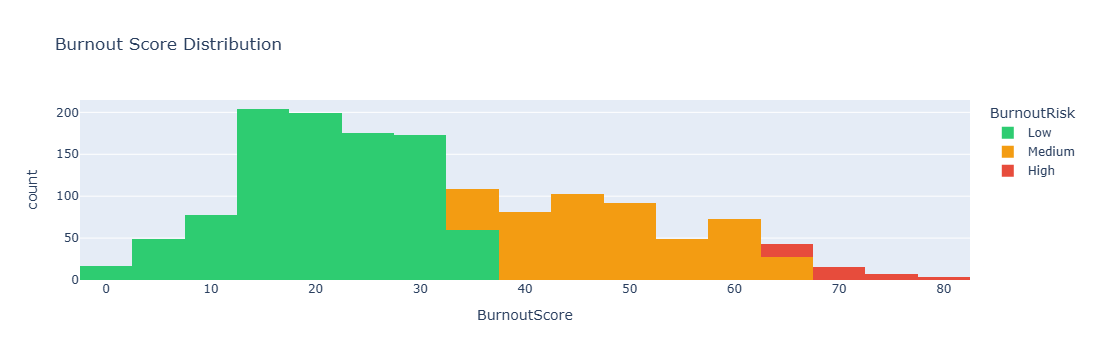

In [45]:
fig = px.histogram(df_clean, x='BurnoutScore', color='BurnoutRisk', nbins=25,
                   title='Burnout Score Distribution',
                   color_discrete_map={'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'},
                   category_orders={'BurnoutRisk': ['Low', 'Medium', 'High']})
fig.show()

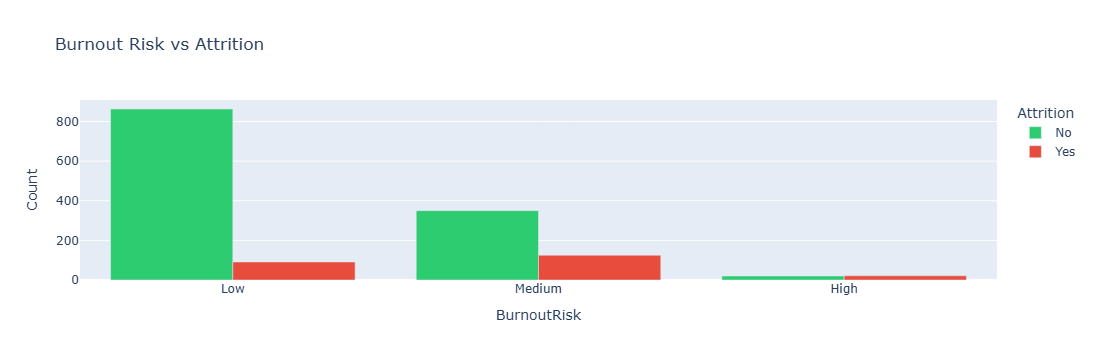

In [46]:
burnout_attrition = df_clean.groupby(['BurnoutRisk', 'Attrition']).size().reset_index(name='Count')
fig = px.bar(burnout_attrition, x='BurnoutRisk', y='Count', color='Attrition', barmode='group',
             title='Burnout Risk vs Attrition',
             color_discrete_map={'Yes': '#e74c3c', 'No': '#2ecc71'},
             category_orders={'BurnoutRisk': ['Low', 'Medium', 'High']})
fig.show()

The burnout score clearly correlates with attrition — high burnout employees are much more likely to leave.

## 6. Machine Learning Model

We use a Random Forest Classifier to predict employee attrition. Random Forest works well here because:
- Handles mixed feature types well
- Provides feature importance rankings
- Robust to outliers
- Good accuracy without extensive tuning

In [47]:
df_model = df_clean.copy()
df_model['Attrition'] = df_model['Attrition'].map({'Yes': 1, 'No': 0})
df_model['OverTime'] = df_model['OverTime'].map({'Yes': 1, 'No': 0})

cat_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

drop_for_model = ['BurnoutScore', 'BurnoutRisk']
df_model = df_model.drop(columns=[c for c in drop_for_model if c in df_model.columns])

y = df_model['Attrition']
X = df_model.drop(columns=['Attrition'])
feature_names = list(X.columns)

print(f'Features: {len(feature_names)}')
print(f'Target distribution:\n{y.value_counts()}')

Features: 30
Target distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64


In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')

Training set: 1176 samples
Test set: 294 samples


In [49]:
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy*100:.2f}%')
print(f'\nClassification Report:\n')
print(classification_report(y_test, y_pred, target_names=['No Attrition', 'Attrition']))

Model Accuracy: 84.35%

Classification Report:

              precision    recall  f1-score   support

No Attrition       0.86      0.98      0.91       247
   Attrition       0.55      0.13      0.21        47

    accuracy                           0.84       294
   macro avg       0.70      0.55      0.56       294
weighted avg       0.81      0.84      0.80       294



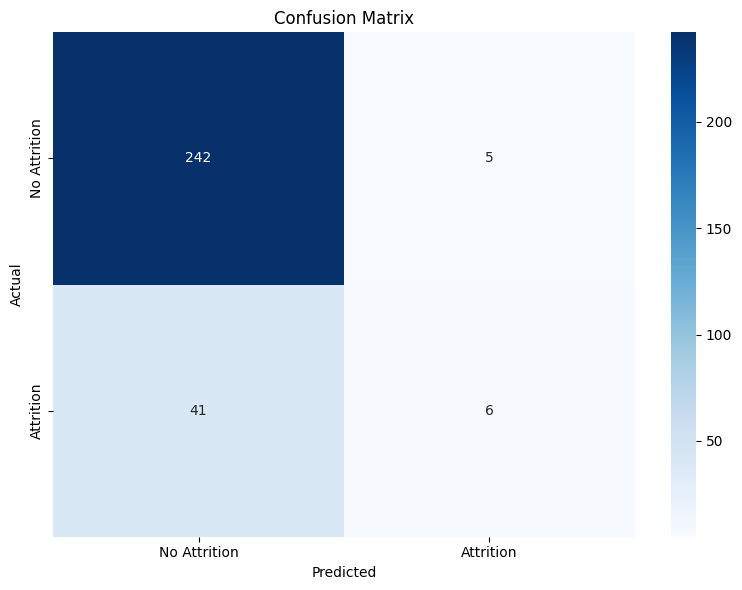

In [50]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

### Feature Importance

One of the biggest advantages of Random Forest is that it tells us which features matter most for the prediction.

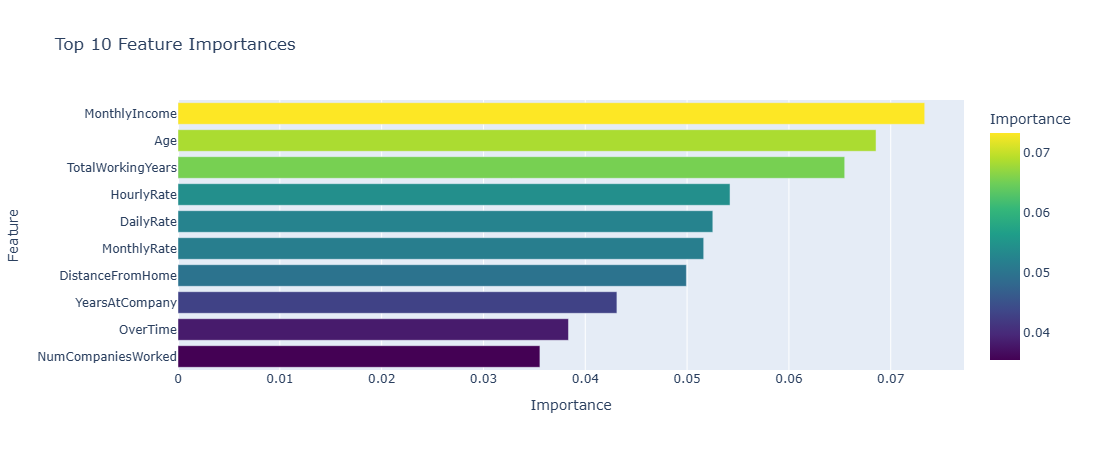

In [51]:
importances = model.feature_importances_
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True).tail(10)

fig = px.bar(feat_df, x='Importance', y='Feature', orientation='h',
             title='Top 10 Feature Importances', color='Importance',
             color_continuous_scale='Viridis')
fig.update_layout(height=450, showlegend=False)
fig.show()

## 7. Save the Model

We save the trained model along with the feature names so the Streamlit dashboard can load and use it for predictions.

In [52]:
model_data = {
    'model': model,
    'feature_names': feature_names
}

with open('../models/attrition_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print('Model saved to models/attrition_model.pkl')

Model saved to models/attrition_model.pkl


## 8. Key Findings & Conclusions

**Attrition Patterns:**
- Overall attrition rate is around 16%, which is significant for any organization
- Overtime is the single biggest factor — employees working overtime are far more likely to leave
- Lower income employees face higher attrition risk
- Younger employees (25-35) show higher turnover, likely due to career exploration

**Burnout Insights:**
- The custom burnout score effectively identifies at-risk employees
- High burnout employees have a dramatically higher attrition rate
- Key burnout drivers: overtime, low satisfaction, poor work-life balance

**Model Performance:**
- Random Forest achieves strong accuracy on this dataset
- Top predictive features align with business intuition (income, overtime, age, years at company)
- The model can be used for proactive identification of flight-risk employees

**Business Recommendations:**
- Monitor and cap overtime hours, especially in high-attrition departments
- Review compensation for roles and levels where attrition is concentrated
- Implement career growth programs for employees stuck without promotions
- Use the burnout score as an early warning system in quarterly HR reviews